# Basic AutoEncoder Anomaly Detector
Loss func: MSE

In [ ]:
# Download the dataset, setup packages
import os
import cv2
import numpy as np
import numpy.typing as npt
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, roc_auc_score

import torch as torch
import torch.nn as nn
import torch.optim as optim

# SSIM addition
!pip install pytorch-msssim -q
from pytorch_msssim import ssim

if not os.path.exists('dataset.zip'):
  !gdown 1_pRKXtYRjWjY0seYqyx25nOxjtr-mHYg
  !unzip -q -u dataset.zip
else:
  print('Already downloaded')

Already downloaded


In [ ]:
import random
def set_seed(seed=77):
    """Locks down all random number generators for reproducibility."""
    # 1. Python built-in random module
    random.seed(seed)

    # 2. NumPy (This fixes your np.random.choice issue!)
    np.random.seed(seed)

    # 3. PyTorch (CPU and GPU)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    # 4. CuDNN (GPU backend)
    # Note: Forcing deterministic behavior can slightly slow down training
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Call this immediately!
set_seed(77)

In [ ]:
# Some helper functions
def load_dataset(class_name = 'pasta'):
  assert class_name in ['pasta', 'screws', 'capsule']
  dir = './dataset/'+class_name+'/'
  training_images = []
  testing_images = []
  testing_labels = []
  for file_name in os.listdir(dir+'train/good/'):
    training_images.append(cv2.cvtColor(cv2.imread(dir+'train/good/'+file_name), cv2.COLOR_BGR2RGB))
  for file_name in os.listdir(dir+'test/good/'):
    testing_images.append(cv2.cvtColor(cv2.imread(dir+'test/good/'+file_name), cv2.COLOR_BGR2RGB))
    testing_labels.append(0)
  for file_name in os.listdir(dir+'test/bad/'):
    testing_images.append(cv2.cvtColor(cv2.imread(dir+'test/bad/'+file_name), cv2.COLOR_BGR2RGB))
    testing_labels.append(1)

  # returns a normalized (0-1) numpy array of size (n,)
  return np.array(training_images)/255., np.array(testing_images)/255., np.array(testing_labels)

def basic_evaluation(predictions : np.ndarray, targets : np.ndarray):
  print(targets)
  print(predictions)
  print('AUROC Score:', roc_auc_score(targets, predictions))

In [ ]:
# What size to make latent vector dim?
class Encoder(nn.Module):
    def __init__(self, image_height, image_width, latent_vector_dim = 16):
        super().__init__()

        '''
        Encoder has 3 3x3 convolutional layers which reduces dimensions in half each layer (stride = 2). These layers act as feature extractors

        Recall: stride is how many pixels filter slides (produces less outputs for bigger stride). It is 'learned downsampling'.
                In contrast pooling throws away backgroud noise and has no 'learning'
        '''

        self.convolution = nn.Sequential(
            # (in_channels, out_channels, kernel_size, stride, padding)
            nn.Conv2d(3,16,3,stride=2,padding=1),
            nn.ReLU(),
            nn.Conv2d(16,32,3,stride=2,padding=1),
            nn.ReLU(),
            nn.Conv2d(32,64,3,stride=2,padding=1),
            nn.ReLU(),
            nn.Conv2d(64,128,3,stride=2,padding=1),
            nn.ReLU(),
            # nn.Conv2d(128,256,3,stride=2,padding=1),
            # nn.ReLU()
        )

        '''
        To get these values from latent vector, we use fully connected layer to scale down to 1 param (1 meam and 1 variance) (as mean and variance use all values in vector?)
        Options are nn.Linear(input_dim, output_dim) or nn.LazyLinear(output_dim) which does it for you?

        Using linear as we need these values anyways for our decoder. therefore we have to do a dummy pass to see the output shapes
        '''
        dummy_input = torch.zeros(1, 3, image_height, image_width)
        dummy_output = self.convolution(dummy_input)

        # Save this shape for the decoder to use later
        self.flattened_size = dummy_output.view(1, -1).size(1)
        self.spatial_shape = dummy_output.shape[1:]

        self.fc = nn.Linear(self.flattened_size, latent_vector_dim)

        # # fully connected layer
        # self.fully_connected_mu = nn.LazyLinear(latent_vector_dim)
        # # fully connected layer
        # self.fully_connnected_log_var = nn.LazyLinear(latent_vector_dim)

    def forward(self,x):

        # Go through our convolutional layers
        z = self.convolution(x)

        # flatten output into latent vector
        # if doing 1x1x1 convolution you do not flatten you jsut march on

        x = torch.flatten(z, start_dim =1)

        # change to convolutional 1x1x1
        # now we want our flattened vector to pass through both fc layers to yeild 2 parameters which will act as our mean and variance
        latent_vector = self.fc(x)

        return latent_vector


In [ ]:
class Decoder(nn.Module):
    def __init__(self, latent_vector_dim, flattened_size, spatial_shape):
        super().__init__()
        self.spatial_shape = spatial_shape

        self.fully_connected_decoder_in = nn.Linear(latent_vector_dim, flattened_size)

        # decoder mirrors encoder and reverses to reconstruct the spacial resolution
        self.decoder = nn.Sequential(
            nn.Unflatten(1,self.spatial_shape),
            # nn.ConvTranspose2d(256,128,4,stride=2,padding=1),
            # nn.ReLU(),
            nn.ConvTranspose2d(128,64,4,stride=2,padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(64,32,4,stride=2,padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(32,16,4,stride=2,padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(16,3,4,stride=2,padding=1),
            nn.Sigmoid()
        )


    def forward(self, z):

        # expand the latent vector into an input big enough for our decoder
        x = self.fully_connected_decoder_in(z)
        output = self.decoder(x)
        return output

In [ ]:
def calc_loss(x, recon_out):
  # Reconstruction loss (MSE)
  reconstruction_loss = nn.MSELoss()(recon_out, x)

  # output L = recon_loss + kl_loss
  return reconstruction_loss

In [ ]:

class Basic_AE(nn.Module):
  def __init__(self, image_height, image_width, latent_vector_dim = 16, num_epochs=30):
    super().__init__()

    self.encoder = Encoder(image_height, image_width)

    self.decoder = Decoder(latent_vector_dim, self.encoder.flattened_size, self.encoder.spatial_shape)

  def forward(self, x):
    lv = self.encoder(x)
    reconstructed_output = self.decoder(lv)

    return reconstructed_output



In [ ]:
# made with AI, not in final version
def visualize_reconstructions(model, test_data, num_images=3):
    """Passes a few test images through the model and plots the original vs. reconstruction."""
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    model.eval()

    # Grab a few random images from the test set
    indices = np.random.choice(len(test_data), num_images, replace=False)
    sample_images = test_data[indices]

    # Convert to PyTorch tensor and fix dimensions for model (N, C, H, W)
    x = torch.tensor(sample_images).permute(0, 3, 1, 2).float().to(device)

    #x = torch.clamp(x, 0., 1.)

    with torch.no_grad():
        reconstructed = model(x)

    # Move back to CPU and format for matplotlib (N, H, W, C)
    recon_images = reconstructed.permute(0, 2, 3, 1).cpu().numpy()

    # Plotting
    fig, axes = plt.subplots(num_images, 2, figsize=(6, 2.5 * num_images))
    fig.suptitle("Original vs Reconstructed", fontsize=16)

    for i in range(num_images):
        # Original Image
        axes[i, 0].imshow(sample_images[i])
        axes[i, 0].set_title("Original")
        axes[i, 0].axis('off')

        # Reconstructed Image
        axes[i, 1].imshow(recon_images[i])
        axes[i, 1].set_title("Reconstructed")
        axes[i, 1].axis('off')

    plt.tight_layout()
    plt.show()

In [ ]:
def train_model(model, dataset, num_epochs, learning_rate=1e-3):

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    # convert numpy to torch, need to rearrange the dimensions
    x = torch.tensor(dataset).permute(0,3,1,2).float().to(device)

    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    for epoch in range(num_epochs):

      model.train()

      # compute vae forward
      recon_out = model(x)

      # compute loss
      loss = calc_loss(x, recon_out)

      # clear old gradients from last iter
      optimizer.zero_grad()

      # backward pass for optimization
      loss.backward()

      # update
      optimizer.step()

      print("epoch",epoch,"loss",loss.item())


def predict(model, test_data):

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    model.eval()

    x = torch.tensor(test_data).permute(0,3,1,2).float().to(device)

    with torch.no_grad():

      x_hat = model(x)

      errors = torch.mean((x - x_hat)**2, dim=(1,2,3))

    return errors.cpu().numpy()


screws analysis
epoch 0 loss 0.07939314097166061
epoch 1 loss 0.07900466024875641
epoch 2 loss 0.0783761516213417
epoch 3 loss 0.07688590884208679
epoch 4 loss 0.07301681488752365
epoch 5 loss 0.06450720876455307
epoch 6 loss 0.05467614531517029
epoch 7 loss 0.05998067185282707
epoch 8 loss 0.04963793605566025
epoch 9 loss 0.04334249719977379
epoch 10 loss 0.04292427748441696
epoch 11 loss 0.04153775796294212
epoch 12 loss 0.03812031447887421
epoch 13 loss 0.035182446241378784
epoch 14 loss 0.034199342131614685
epoch 15 loss 0.032963529229164124
epoch 16 loss 0.030494417995214462
epoch 17 loss 0.027997640892863274
epoch 18 loss 0.026523025706410408
epoch 19 loss 0.025930944830179214
epoch 20 loss 0.02546275220811367
epoch 21 loss 0.02477092482149601
epoch 22 loss 0.024141384288668633
epoch 23 loss 0.02385958842933178
epoch 24 loss 0.023637162521481514
epoch 25 loss 0.023130293935537338
epoch 26 loss 0.022588616237044334
epoch 27 loss 0.02232934720814228
epoch 28 loss 0.0221723075956106

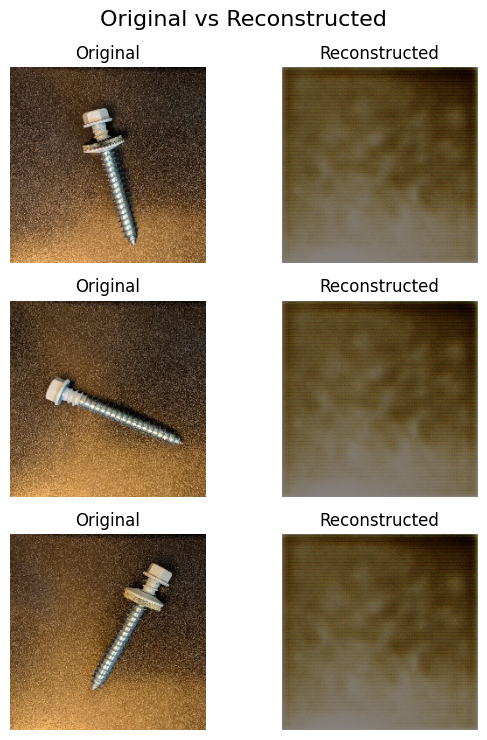

pasta analysis
epoch 0 loss 0.06826253235340118
epoch 1 loss 0.06793290376663208
epoch 2 loss 0.06733251363039017
epoch 3 loss 0.06592550873756409
epoch 4 loss 0.062358975410461426
epoch 5 loss 0.05687406286597252
epoch 6 loss 0.059341251850128174
epoch 7 loss 0.0502859465777874
epoch 8 loss 0.04743724316358566
epoch 9 loss 0.046172209084033966
epoch 10 loss 0.043175287544727325
epoch 11 loss 0.03987336903810501
epoch 12 loss 0.0392303541302681
epoch 13 loss 0.03835001960396767
epoch 14 loss 0.035315241664648056
epoch 15 loss 0.03362536430358887
epoch 16 loss 0.03336751088500023
epoch 17 loss 0.032494693994522095
epoch 18 loss 0.031171264126896858
epoch 19 loss 0.030821947380900383
epoch 20 loss 0.0309440977871418
epoch 21 loss 0.0301938708871603
epoch 22 loss 0.029492076486349106
epoch 23 loss 0.029521552845835686
epoch 24 loss 0.02949974313378334
epoch 25 loss 0.02905484102666378
epoch 26 loss 0.028770217671990395
epoch 27 loss 0.028890982270240784
epoch 28 loss 0.028825566172599792


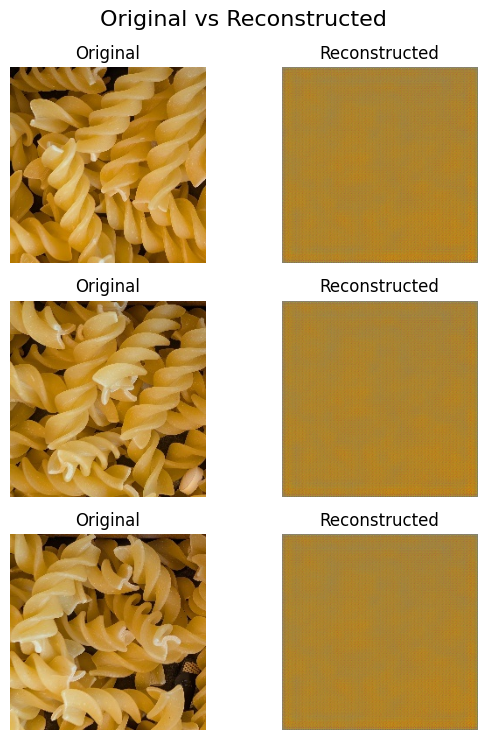

capsule analysis
epoch 0 loss 0.09996982663869858
epoch 1 loss 0.0996093824505806
epoch 2 loss 0.09904778748750687
epoch 3 loss 0.09784506261348724
epoch 4 loss 0.09473136067390442
epoch 5 loss 0.08699651062488556
epoch 6 loss 0.07243900746107101
epoch 7 loss 0.06298848986625671
epoch 8 loss 0.05900150164961815
epoch 9 loss 0.04667237028479576
epoch 10 loss 0.03829102963209152
epoch 11 loss 0.0347810722887516
epoch 12 loss 0.03152454271912575
epoch 13 loss 0.02877291478216648
epoch 14 loss 0.02796712890267372
epoch 15 loss 0.027952643111348152
epoch 16 loss 0.027442095801234245
epoch 17 loss 0.02647043578326702
epoch 18 loss 0.02584611251950264
epoch 19 loss 0.025890382006764412
epoch 20 loss 0.02575601637363434
epoch 21 loss 0.024945072829723358
epoch 22 loss 0.024208463728427887
epoch 23 loss 0.02411702461540699
epoch 24 loss 0.02398681826889515
epoch 25 loss 0.023371240124106407
epoch 26 loss 0.02305619604885578
epoch 27 loss 0.02321852557361126
epoch 28 loss 0.022927584126591682
ep

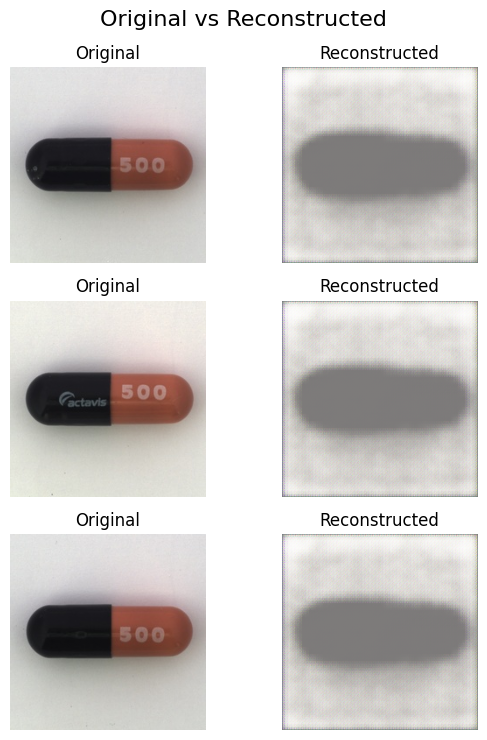

In [ ]:
# TODO use class above as well as helper functions to generate
# predictions on the datasets and evaluate the results.

def do_analysis(class_name):
  training_images, testing_images, testing_labels = load_dataset(class_name=class_name)

  img_height = training_images.shape[1]
  img_width = training_images.shape[2]

  basic_model = Basic_AE(img_height, img_width)

  train_model(basic_model, training_images, num_epochs=30)

  predictions = predict(basic_model, testing_images)
  basic_evaluation(predictions, testing_labels)
  visualize_reconstructions(basic_model, testing_images, num_images=3)

print("screws analysis")
do_analysis('screws')
print("pasta analysis")
do_analysis('pasta')
print("capsule analysis")
do_analysis('capsule')
